In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [2]:
# Генерируем данные
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Обучаем дерево (без ограничений — будет переобучаться)
tree_deep = DecisionTreeClassifier(random_state=42)
tree_deep.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Глубокое дерево (train): 1.0000
Глубокое дерево (test): 0.9000
Обрезанное дерево (train): 0.9667
Обрезанное дерево (test): 0.9333


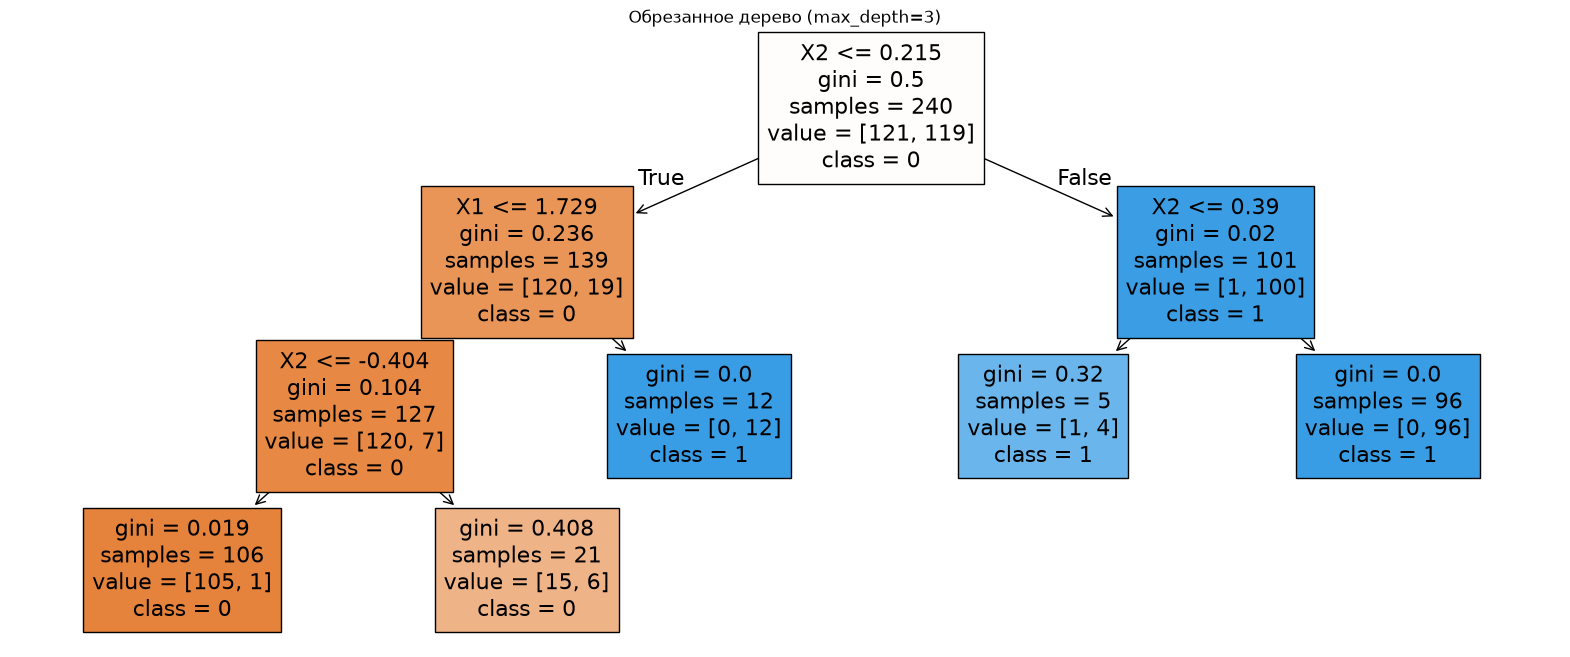

In [ ]:
# Обучаем дерево с ограничениями
tree_pruned = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
tree_pruned.fit(X_train, y_train)

# Оценкаs
print(f"Глубокое дерево (train): {accuracy_score(y_train, tree_deep.predict(X_train)):.4f}")
print(f"Глубокое дерево (test): {accuracy_score(y_test, tree_deep.predict(X_test)):.4f}")
print(f"Обрезанное дерево (train): {accuracy_score(y_train, tree_pruned.predict(X_train)):.4f}")
print(f"Обрезанное дерево (test): {accuracy_score(y_test, tree_pruned.predict(X_test)):.4f}")

# Визуализация структуры
plt.figure(figsize=(20, 8))
plot_tree(tree_pruned, feature_names=['X1', 'X2'], class_names=['0', '1'], filled=True)
plt.title("Обрезанное дерево (max_depth=3)")
plt.show()

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

In [11]:
# ===============================
# 1. ДАННЫЕ
# ===============================
data = fetch_openml(data_id=31, as_frame=True)
df = data.frame
y = data.target.map({'good': 1, 'bad': 0}).astype(int)
X = df.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# ===============================
# 2. ПРЕПРОЦЕССОР
# ===============================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()


In [14]:
# Для XGBoost числовые признаки можно не стандартизировать
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

In [19]:
# ===============================
# 3. ПАЙПЛАЙН + XGBOOST
# ===============================
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=4,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])
# ===============================
# 4. ОБУЧЕНИЕ
# ===============================
pipeline_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [20]:
# ===============================
# 5. ОЦЕНКА
# ===============================
y_pred = pipeline_xgb.predict(X_test)
y_proba = pipeline_xgb.predict_proba(X_test)[:, 1]

print("="*60)
print("XGBOOST (БАЗОВЫЙ)")
print("="*60)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBOOST (БАЗОВЫЙ)
ROC-AUC: 0.8216

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.53      0.61        59
           1       0.82      0.92      0.87       141

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200



In [17]:
# ===============================
# 6. ВАЖНОСТЬ ПРИЗНАКОВ
# ===============================
xgb_model = pipeline_xgb.named_steps['classifier']
importances = xgb_model.feature_importances_
importances

array([0.02073681, 0.01604119, 0.01439936, 0.01179919, 0.01708352,
       0.00955883, 0.01660558, 0.00624515, 0.01995421, 0.03005007,
       0.11614685, 0.01707149, 0.02580108, 0.01921173, 0.01219747,
       0.02219128, 0.01345392, 0.        , 0.01998664, 0.01938784,
       0.02103298, 0.        , 0.016206  , 0.00847954, 0.        ,
       0.01312151, 0.0092799 , 0.02161463, 0.02017955, 0.01409964,
       0.01953795, 0.01116819, 0.016568  , 0.01120341, 0.01542557,
       0.01970737, 0.01356237, 0.01354125, 0.        , 0.01392418,
       0.00999902, 0.01680463, 0.06338641, 0.01054858, 0.01019975,
       0.02892965, 0.02229688, 0.01557116, 0.02559257, 0.01097691,
       0.00795954, 0.014067  , 0.01730638, 0.01433442, 0.00881316,
       0.        , 0.01865436, 0.01204576, 0.        , 0.0059395 ,
       0.        ], dtype=float32)

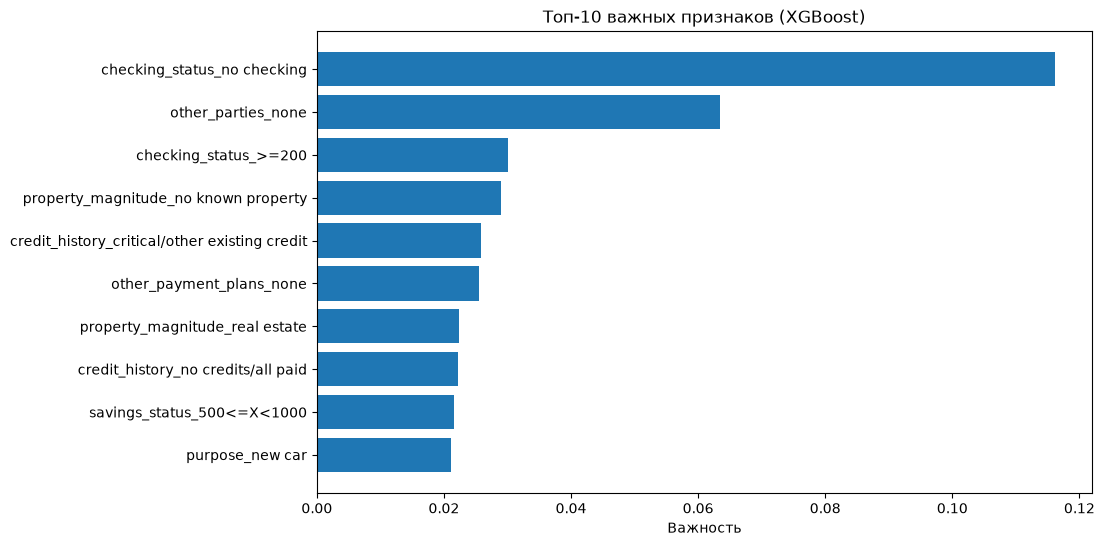

In [18]:
# Получаем имена признаков после OHE
cat_feature_names = list(pipeline_xgb.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .get_feature_names_out(cat_cols))
all_feature_names = num_cols + cat_feature_names

# Топ-10
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10, 6))
plt.title("Топ-10 важных признаков (XGBoost)")
plt.barh(range(10), importances[indices][::-1], align='center')
plt.yticks(range(10), [all_feature_names[i] for i in indices[::-1]])
plt.xlabel("Важность")
plt.show()

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Генерируем данные
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


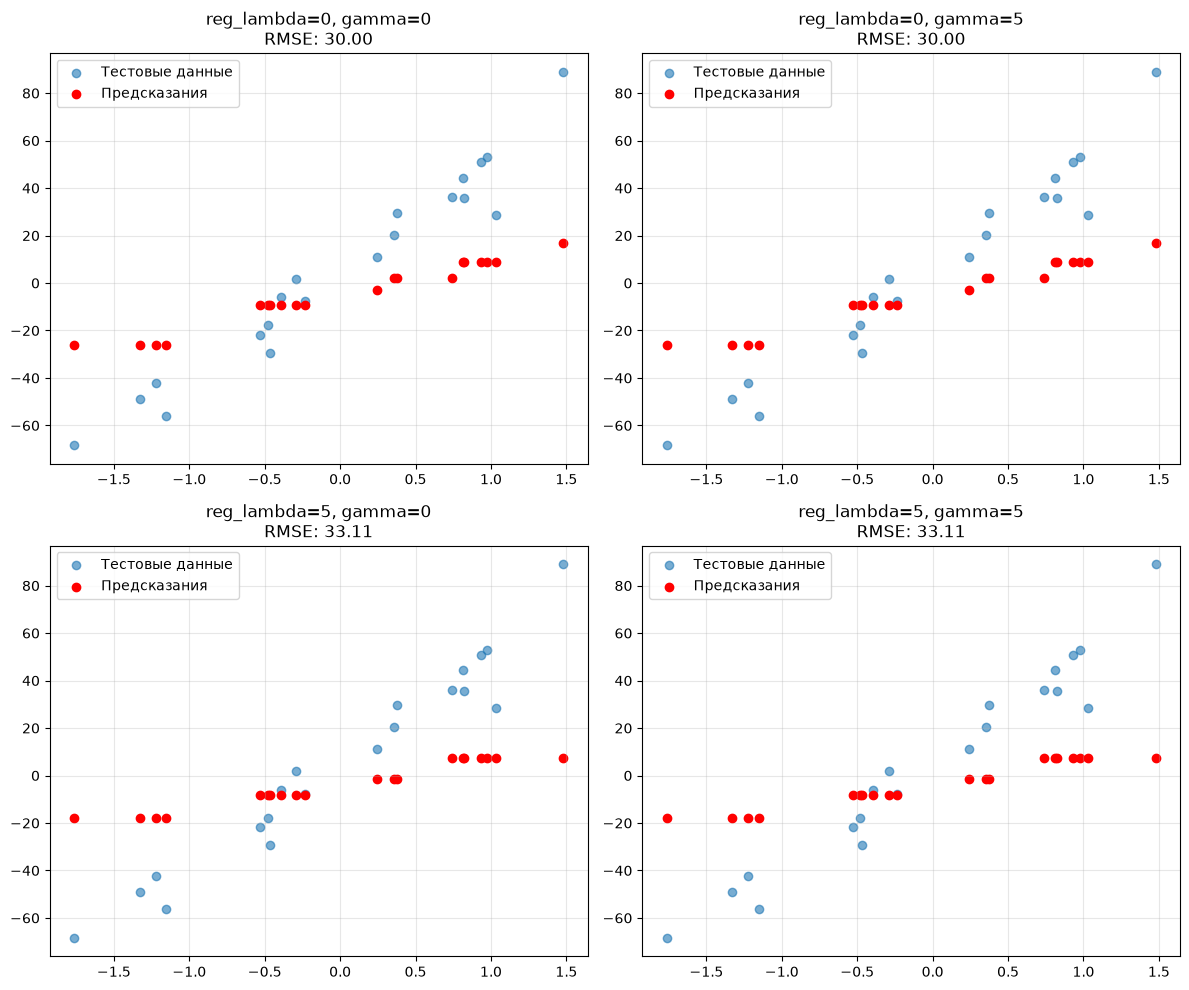

In [23]:

# Функция для обучения и визуализации
def train_and_plot(reg_lambda, gamma, ax):
    model = xgb.XGBRegressor(
        n_estimators=1,  # Одно дерево, чтобы видеть структуру
        max_depth=3,
        reg_lambda=reg_lambda,
        gamma=gamma,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test)
    
    # Визуализация
    ax.scatter(X_test, y_test, alpha=0.6, label='Тестовые данные')
    ax.scatter(X_test, y_pred, color='red', label='Предсказания')
    ax.set_title(f'reg_lambda={reg_lambda}, gamma={gamma}\nRMSE: {np.sqrt(np.mean((y_test - y_pred)**2)):.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Сравниваем разные комбинации
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

params = [
    (0, 0),    # Без регуляризации
    (0, 5),    # Только gamma
    (5, 0),    # Только reg_lambda
    (5, 5)     # Оба
]

for ax, (reg_lambda, gamma) in zip(axes.ravel(), params):
    train_and_plot(reg_lambda, gamma, ax)

plt.tight_layout()
plt.show()

RMSE: 13.60


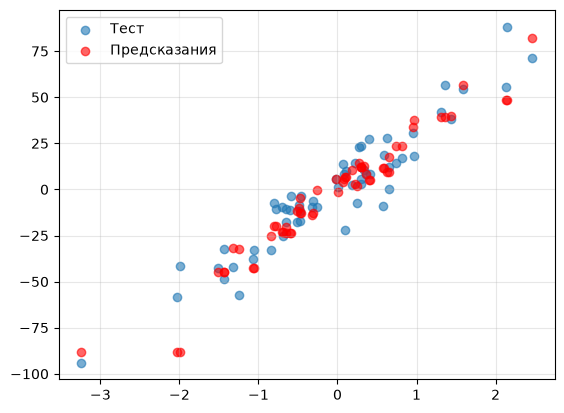

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Генерация данных
X, y = make_regression(n_samples=300, n_features=1, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Модель с адекватными параметрами
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

# Визуализация
plt.scatter(X_test, y_test, alpha=0.6, label='Тест')
plt.scatter(X_test, y_pred, alpha=0.6, color='red', label='Предсказания')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
pip install catboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.2 MB/s eta 0:01:26
   ---------------------------------------- 0.8/101.7 MB 1.2 MB/s eta 0:01:21
   ---------------------------------------- 1.0/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 1.6/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 2.1/101.7 MB 1.6 MB/s eta 0:01:02
    --------------------------------------- 2.4/101.7 MB 1.7 MB/s eta 0:01:00
    --------------------------------------- 2.4/101.7 MB 1.7 MB/s eta 0:01:00
   - -------------------------------------- 3.1/101.7 MB 1.6 MB/s eta 0:01:01
   - -------------------------------------- 3.1/101.7 MB 1.6 MB/s eta 0:01:01
   - -------------------------------------- 3.1/101.7 MB 1.6 MB/s eta 0:01:01
   - -------------------------------------- 3.1/101.7 MB 1.6 MB/s eta 0:01:01


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
import lightgbm as lgb

In [28]:
# Загрузка данных
data = fetch_openml(data_id=31, as_frame=True)
df = data.frame
y = data.target.map({'good': 1, 'bad': 0}).astype(int)
X = df.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Препроцессор
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()


In [29]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Пайплайн с LightGBM
pipeline_lgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.1,
        random_state=42,
        verbose=-1
    ))
])

# Обучение
pipeline_lgb.fit(X_train, y_train)

# Оценка
y_pred = pipeline_lgb.predict(X_test)
y_proba = pipeline_lgb.predict_proba(X_test)[:, 1]


LIGHTGBM
ROC-AUC: 0.8133

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.53      0.61        59
           1       0.82      0.91      0.87       141

    accuracy                           0.80       200
   macro avg       0.77      0.72      0.74       200
weighted avg       0.79      0.80      0.79       200



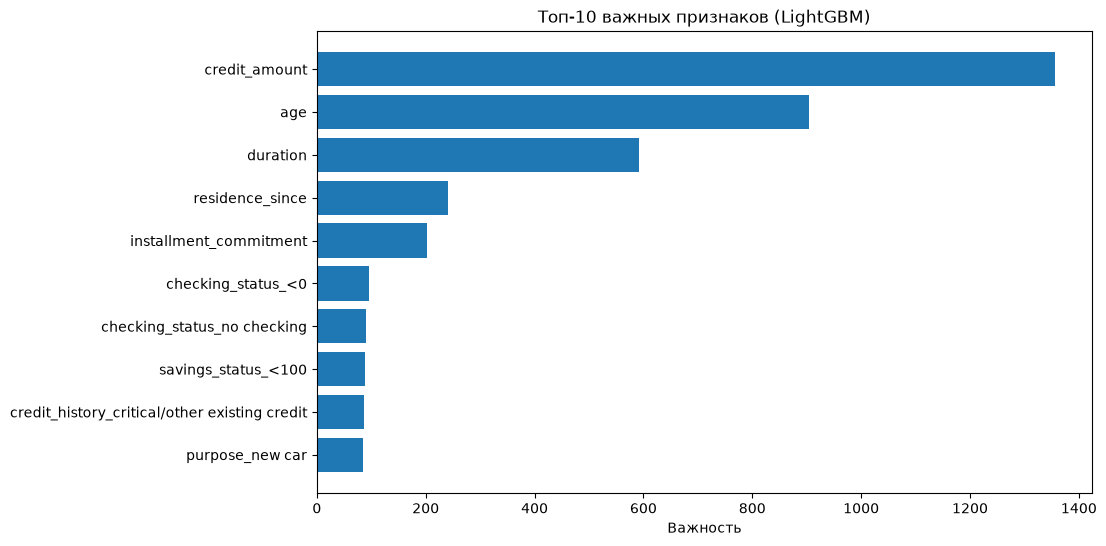

In [30]:
print("="*60)
print("LIGHTGBM")
print("="*60)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Важность признаков
lgb_model = pipeline_lgb.named_steps['classifier']
importances = lgb_model.feature_importances_

cat_feature_names = list(pipeline_lgb.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .get_feature_names_out(cat_cols))
all_feature_names = num_cols + cat_feature_names

indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10, 6))
plt.title("Топ-10 важных признаков (LightGBM)")
plt.barh(range(10), importances[indices][::-1], align='center')
plt.yticks(range(10), [all_feature_names[i] for i in indices[::-1]])
plt.xlabel("Важность")
plt.show()

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Генерируем сложные данные (нелинейные, с шумом)
X, y = make_classification(n_samples=5000, n_features=10, n_informative=5, n_redundant=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Функция для обучения и оценки
def evaluate_lgb(num_leaves, min_child_samples, subsample, colsample_bytree):
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=1.0,
        reg_alpha=0.1,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    return train_auc, test_auc

# Тестируем разные комбинации
configs = [
    (31, 20, 0.8, 0.8),   # Базовый
    (127, 5, 1.0, 1.0),   # Сложный (переобучение)
    (15, 50, 0.6, 0.6),   # Простой (недообучение)
]

for idx, (num_leaves, min_child_samples, subsample, colsample) in enumerate(configs):
    train_auc, test_auc = evaluate_lgb(num_leaves, min_child_samples, subsample, colsample)
    print(f"Config {idx+1}: num_leaves={num_leaves}, min_child_samples={min_child_samples}")
    print(f"  Train AUC: {train_auc:.4f}, Test AUC: {test_auc:.4f}")
    print()

Config 1: num_leaves=31, min_child_samples=20
  Train AUC: 0.9967, Test AUC: 0.9780

Config 2: num_leaves=127, min_child_samples=5
  Train AUC: 1.0000, Test AUC: 0.9770

Config 3: num_leaves=15, min_child_samples=50
  Train AUC: 0.9881, Test AUC: 0.9754



CATBOOST
ROC-AUC: 0.8229

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.51      0.58        59
           1       0.81      0.89      0.85       141

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200



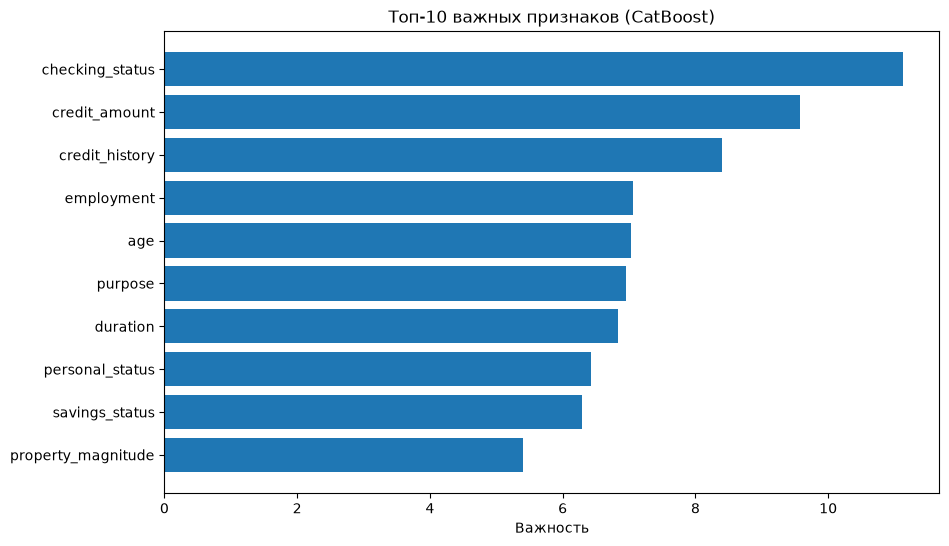

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from catboost import CatBoostClassifier

# Загрузка данных
data = fetch_openml(data_id=31, as_frame=True)
df = data.frame
y = data.target.map({'good': 1, 'bad': 0}).astype(int)
X = df.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Категориальные признаки (CatBoost умеет их принимать "как есть")
cat_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

# Обучаем CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=1.0,
    cat_features=cat_features,
    verbose=False,
    random_state=42
)

model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("="*60)
print("CATBOOST")
print("="*60)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Важность признаков
importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:10]
feature_names = X.columns.tolist()

plt.figure(figsize=(10, 6))
plt.title("Топ-10 важных признаков (CatBoost)")
plt.barh(range(10), importances[indices][::-1], align='center')
plt.yticks(range(10), [feature_names[i] for i in indices[::-1]])
plt.xlabel("Важность")
plt.show()

Ваша версия CatBoost не поддерживает визуализацию деревьев. Используйте plot_tree из другой библиотеки.


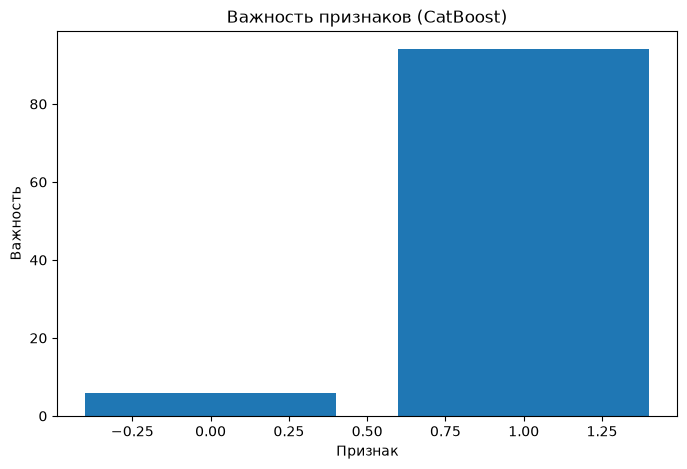

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Генерируем данные
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем модель
model = CatBoostClassifier(
    iterations=10,
    depth=3,
    verbose=False,
    random_state=42
)
model.fit(X_train, y_train)

# Визуализация текста дерева (новый API)
try:
    # Способ 1: get_tree_text с параметрами
    tree_text = model.get_tree_text(0, trees_count=1)
    print("Первое дерево (текст):")
    print(tree_text[:500])
except AttributeError:
    # Способ 2: tree_to_code (альтернатива)
    try:
        tree_code = model.tree_to_code(0)
        print("Первое дерево (код):")
        print(tree_code)
    except AttributeError:
        print("Ваша версия CatBoost не поддерживает визуализацию деревьев. Используйте plot_tree из другой библиотеки.")

# Визуализация важности признаков (работает всегда)
importances = model.feature_importances_
plt.figure(figsize=(8, 5))
plt.bar(range(len(importances)), importances)
plt.title("Важность признаков (CatBoost)")
plt.xlabel("Признак")
plt.ylabel("Важность")
plt.show()